# MNIST 이미지 분류 - CNN

MNIST 손글씨 숫자(28x28 흑백)에 CNN(Conv2D + MaxPooling2D)을 적용하는 노트북입니다.
CIFAR-10 CNN(`cnn_cifar10.ipynb`)과 같은 계열의 구조를, 더 단순한 흑백 데이터셋에 적용해본 버전입니다.

- **Dataset**: `keras.datasets.mnist` — 28x28 흑백 손글씨 숫자(0~9)
- **모델**: Conv2D(32) → MaxPool → Conv2D(64) → MaxPool → Dropout(0.25) → Flatten → Dense(128) → Dense(10, softmax)
- **다루는 내용**: CNN 기본 구조 구현, 예측 성공/실패 샘플 시각화


## 0. 함수 정의

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np
import random
import time


def load_data():
    (X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()
    X_train_full = X_train_full.astype(np.float32)
    X_test = X_test.astype(np.float32)
    return X_train_full, y_train_full, X_test, y_test


def data_normalization(X_train_full, X_test):
    """0~255 픽셀값을 0~1로 정규화하고, CNN 입력에 맞게 채널 차원을 추가한다 (28,28) -> (28,28,1)."""
    X_train_full = X_train_full / 255.0
    X_test = X_test / 255.0
    train_feature = np.expand_dims(X_train_full, axis=3)
    test_feature = np.expand_dims(X_test, axis=3)
    print(train_feature.shape, test_feature.shape)
    return train_feature, test_feature


def makemodel(X_train, y_train, X_valid, y_valid, epochs=20):
    """MNIST용 CNN: Conv2D(32) -> MaxPool -> Conv2D(64) -> MaxPool -> Dropout -> Flatten -> Dense(128) -> Dense(10)"""
    model = Sequential()
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(MaxPooling2D(pool_size=2))
    model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=2))
    model.add(Dropout(0.25))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    tb_hist = keras.callbacks.TensorBoard(log_dir='./graph', histogram_freq=0, write_graph=True, write_images=True)
    start = time.time()
    history = model.fit(X_train, y_train, epochs=epochs, validation_data=(X_valid, y_valid), callbacks=[tb_hist])
    print("time :", time.time() - start)
    return model, history


def plot_history(history, key='accuracy'):
    plt.figure(figsize=(10, 6))
    plt.plot(history.epoch, history.history['val_' + key], '--', label='Val')
    plt.plot(history.epoch, history.history[key], label='Train')
    plt.xlabel('Epochs')
    plt.ylabel(key.title())
    plt.legend()
    plt.show()


def draw_prediction(indices, k, X_test, y_test, yhat):
    samples = random.choices(population=indices, k=k)
    plt.figure(figsize=(12, 8))
    for count, n in enumerate(samples, start=1):
        plt.subplot(4, 4, count)
        plt.imshow(X_test[n].reshape(28, 28), cmap='Greys', interpolation='nearest')
        plt.title(f"Label:{y_test[n]}, Prediction:{yhat[n]}")
    plt.tight_layout()
    plt.show()


def evalmodel(X_test, y_test, model):
    yhat = model.predict(X_test)
    yhat = yhat.argmax(axis=1)

    correct = [n for n in range(len(y_test)) if yhat[n] == y_test[n]]
    wrong = [n for n in range(len(y_test)) if yhat[n] != y_test[n]]

    draw_prediction(correct, 16, X_test, y_test, yhat)
    draw_prediction(wrong, 16, X_test, y_test, yhat)


## 1. 실행
데이터 로드 → 정규화 → 학습 → 평가/시각화까지 한 번에 실행한다.

(60000, 28, 28, 1) (10000, 28, 28, 1)
Epoch 1/20
1875/1875 [==============================] - 25s 13ms/step - loss: 0.1417 - accuracy: 0.9565 - val_loss: 0.0483 - val_accuracy: 0.9849
Epoch 2/20
1875/1875 [==============================] - 28s 15ms/step - loss: 0.0498 - accuracy: 0.9847 - val_loss: 0.0322 - val_accuracy: 0.9899
Epoch 3/20
1875/1875 [==============================] - 32s 17ms/step - loss: 0.0356 - accuracy: 0.9884 - val_loss: 0.0352 - val_accuracy: 0.9872
Epoch 4/20
1875/1875 [==============================] - 40s 22ms/step - loss: 0.0276 - accuracy: 0.9914 - val_loss: 0.0314 - val_accuracy: 0.9893
Epoch 5/20
1875/1875 [==============================] - 39s 21ms/step - loss: 0.0232 - accuracy: 0.9922 - val_loss: 0.0271 - val_accuracy: 0.9919
Epoch 6/20
1875/1875 [==============================] - 32s 17ms/step - loss: 0.0190 - accuracy: 0.9941 - val_loss: 0.0333 - val_accuracy: 0.9901
Epoch 7/20
1875/1875 [==============================] - 27s 15ms/step - loss: 0.0166 -

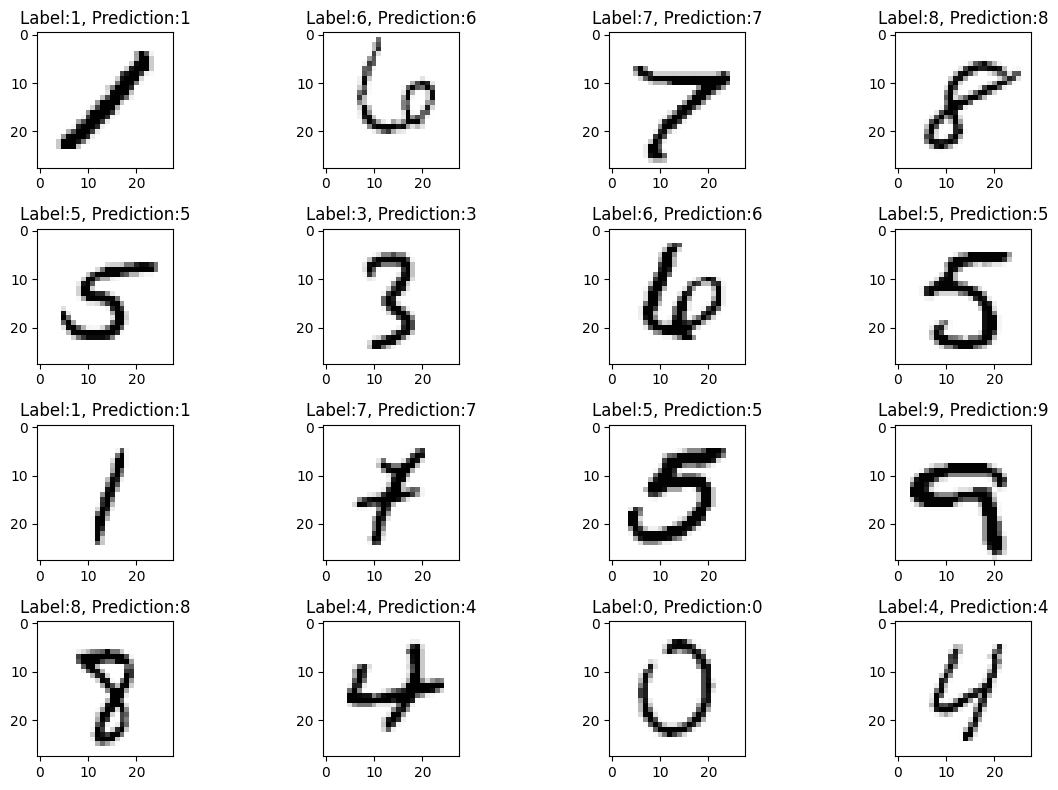

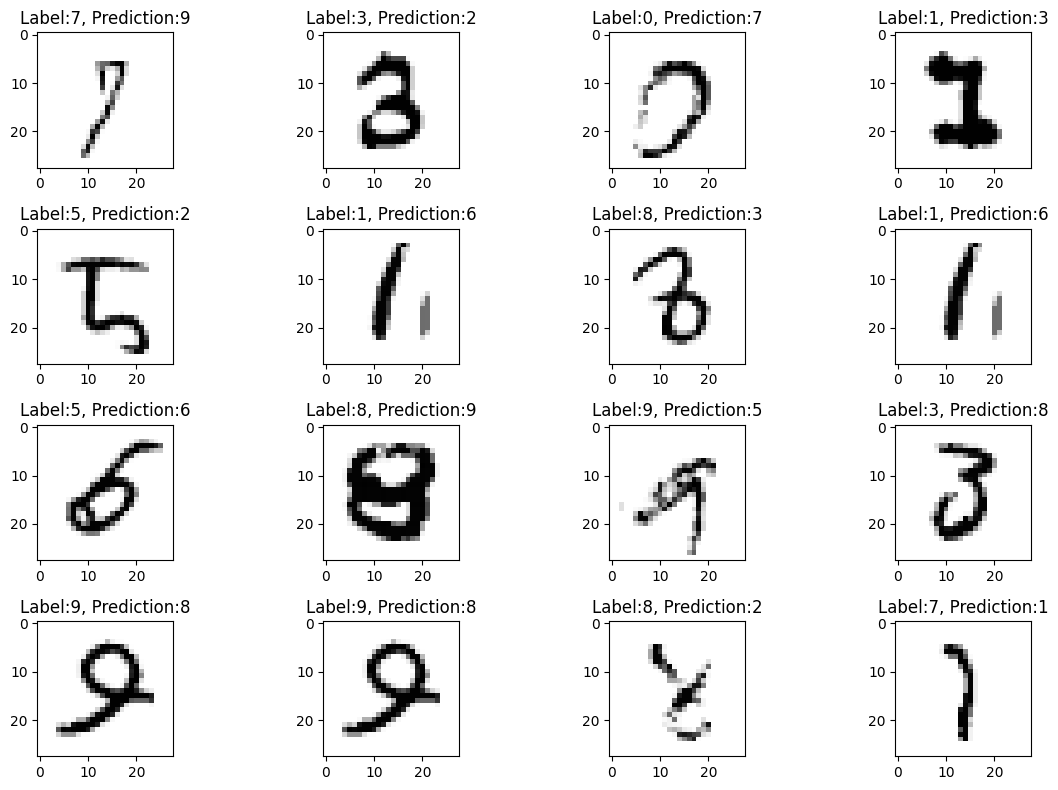

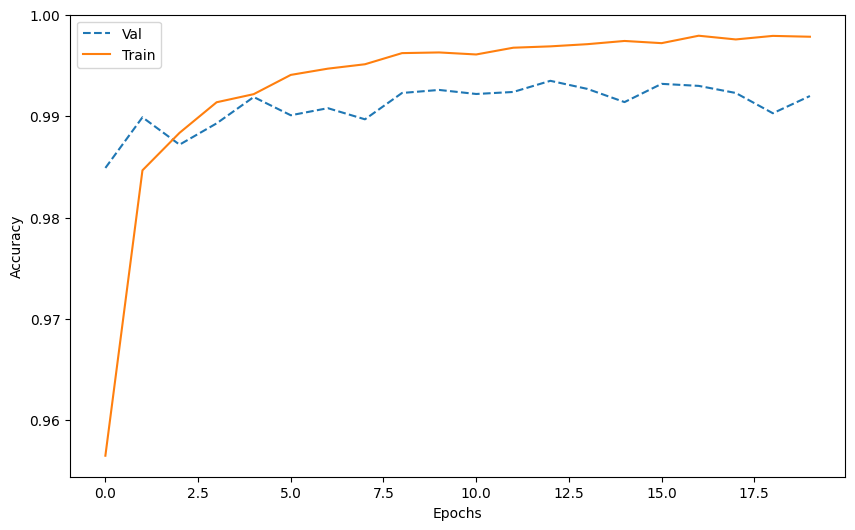

In [7]:
X_train_full, y_train_full, X_test, y_test = load_data()
X_train, X_test = data_normalization(X_train_full, X_test)

model, history = makemodel(X_train, y_train_full, X_test, y_test, epochs=20)
evalmodel(X_test, y_test, model)
plot_history(history)
